# 01 — EDA: FineBadminton Dataset

Exploratory analysis of the FineBadminton annotation JSON.  
Covers: dataset structure, shot-type distribution, strategy distribution, and shot × strategy correlations.

In [1]:
import json
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter, defaultdict
from pathlib import Path

sns.set_theme(style='whitegrid', palette='muted')

ANNOT_PATH = '../Datasets/FineBadminton-dataset/dataset/transformed_combined_rounds_output_en_evals_translated.json'

## 1. Load annotations

In [11]:
with open(ANNOT_PATH) as f:
    data = json.load(f)

# Flatten all shots
shots = []
for rally in data:
    for hit in rally.get('hitting', []):
        hit['video'] = rally['video']
        shots.append(hit)

df = pd.DataFrame(shots)
df['has_strategy'] = df['strategies'].apply(lambda x: isinstance(x, list) and len(x) > 0)

print(f'Rallies:              {len(data)}')
print(f'Total shots:          {len(df)}')
print(f'Shots with strategy:  {df["has_strategy"].sum()}')
print(f'Unique shot types:    {df["hit_type"].nunique()}')
print(f'Unique players:       {df["player"].nunique()}')
df

Rallies:              40
Total shots:          414
Shots with strategy:  355
Unique shot types:    12
Unique players:       19


,start_frame,end_frame,player,hit_type,subtype,quality,comment,hit_frame,get_point,ball_area,...,shot_characteristics,video,strategies,hit_outcomes,hit_area_zh,changed,start_frame_rally,end_frame_rally,hit_frame_rally,has_strategy
0,16362.0,16378.0,Kento MOMOTA,serve,[short serve],4,top player a backhand short serve,16363,[],mid front court,...,[cross-court],0011_001.mp4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
1,16378.0,16400.0,Viktor AXELSEN,push shot,[flat lift],4,"Bottom backhand push-lift, overhead cross-cour...",16380,[],mid front court,...,"[cross-court, over head]",0011_001.mp4,[To create depth],NaN,NaN,NaN,NaN,NaN,NaN,True
2,16400.0,16425.0,Kento MOMOTA,drop shot,[slice drop shot],5,Top forehand slice drop shot straight to the o...,16411,[],left back court,...,[straight],0011_001.mp4,[intercept],NaN,NaN,NaN,NaN,NaN,NaN,True
3,16425.0,16448.0,Viktor AXELSEN,block,[],5,"From his own right front court, Bottom softly ...",16429,[],right front court,...,[cross-court],0011_001.mp4,[defensive],NaN,NaN,NaN,NaN,NaN,NaN,True
4,16448.0,16477.0,Kento MOMOTA,push shot,[flat lift],3,Top moves from the left backcourt to his own l...,16451,[],left front court,...,[straight],0011_001.mp4,"[move to the net, passive]",NaN,NaN,NaN,NaN,NaN,NaN,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
409,4273.0,4298.0,Ng Ka Long Angus,net shot,[],6,Top moves from mid-backcourt to the left front...,4281,[],left front court,...,[straight],0030_004.mp4,"[a high net early shot, move to the net, seaml...",NaN,NaN,NaN,NaN,NaN,NaN,True
410,4298.0,4340.0,Viktor Axelsen,net lift,[high lift],2,The player at the bottom moved to the net to t...,4305,[],right front court,...,"[cross-court, over head]",0030_004.mp4,"[To create depth, move to the net, passive]",NaN,NaN,NaN,NaN,NaN,NaN,True
411,4340.0,4360.0,Ng Ka Long Angus,kill,"[full smash, jump smash]",6,Top performs a forehand jump smash cross-court...,4354,[],mid back court,...,[cross-court],0030_004.mp4,[intercept],NaN,NaN,NaN,NaN,NaN,NaN,True
412,4360.0,4376.0,Viktor Axelsen,push shot,[],2,"Bottom, from his right mid-court position, pla...",4364,[],right mid court,...,[cross-court],0030_004.mp4,[passive],NaN,NaN,NaN,NaN,NaN,NaN,True


## 2. Shot-type distribution

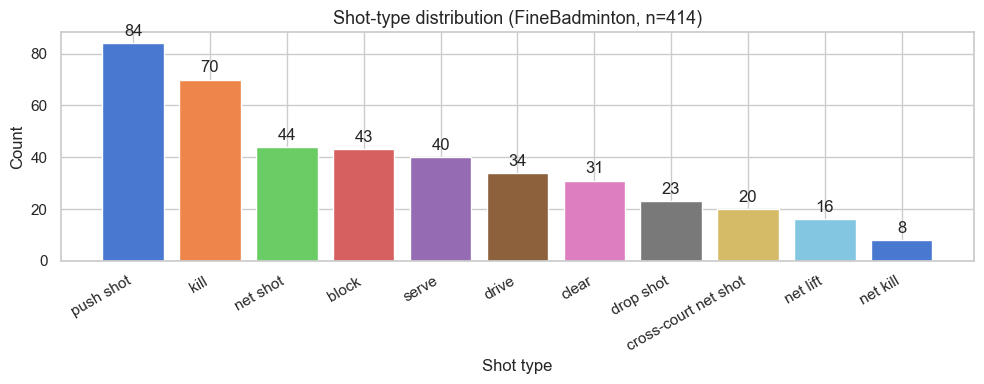

In [12]:
shot_counts = df['hit_type'].value_counts().drop('', errors='ignore')

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(shot_counts.index, shot_counts.values, color=sns.color_palette('muted', len(shot_counts)))
ax.bar_label(bars, padding=3)
ax.set_title('Shot-type distribution (FineBadminton, n=414)', fontsize=13)
ax.set_ylabel('Count')
ax.set_xlabel('Shot type')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('../results/eda_shot_distribution.png', dpi=150)
plt.show()

## 3. Strategy distribution

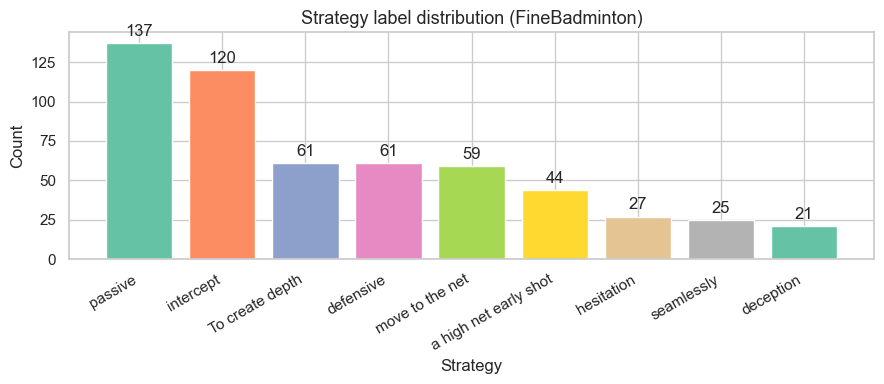

In [4]:
all_strats = [s for strats in df['strategies'].dropna() for s in (strats if isinstance(strats, list) else [])]
strat_counts = Counter(all_strats)

labels, values = zip(*strat_counts.most_common())
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(labels, values, color=sns.color_palette('Set2', len(labels)))
ax.bar_label(bars, padding=3)
ax.set_title('Strategy label distribution (FineBadminton)', fontsize=13)
ax.set_ylabel('Count')
ax.set_xlabel('Strategy')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('../results/eda_strategy_distribution.png', dpi=150)
plt.show()

## 4. Shot × Strategy co-occurrence heatmap

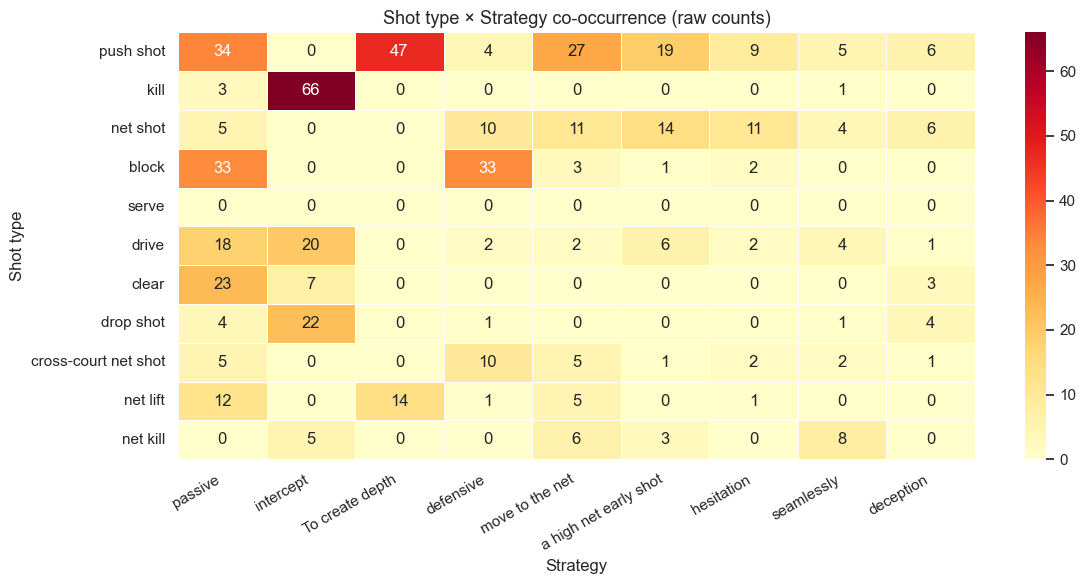

In [5]:
# Build raw count matrix
cross = defaultdict(Counter)
for _, row in df.iterrows():
    ht = row['hit_type']
    if not ht or not isinstance(row.get('strategies'), list):
        continue
    for st in row['strategies']:
        cross[ht][st] += 1

shot_types_ordered = [t for t, _ in Counter(df['hit_type']).most_common() if t]
strat_ordered = [s for s, _ in strat_counts.most_common()]

matrix = pd.DataFrame(
    [[cross[ht][st] for st in strat_ordered] for ht in shot_types_ordered],
    index=shot_types_ordered, columns=strat_ordered
)

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(matrix, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5, ax=ax)
ax.set_title('Shot type × Strategy co-occurrence (raw counts)', fontsize=13)
ax.set_xlabel('Strategy')
ax.set_ylabel('Shot type')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('../results/eda_shot_strategy_heatmap.png', dpi=150)
plt.show()

## 5. Conditional probability P(strategy | shot_type)

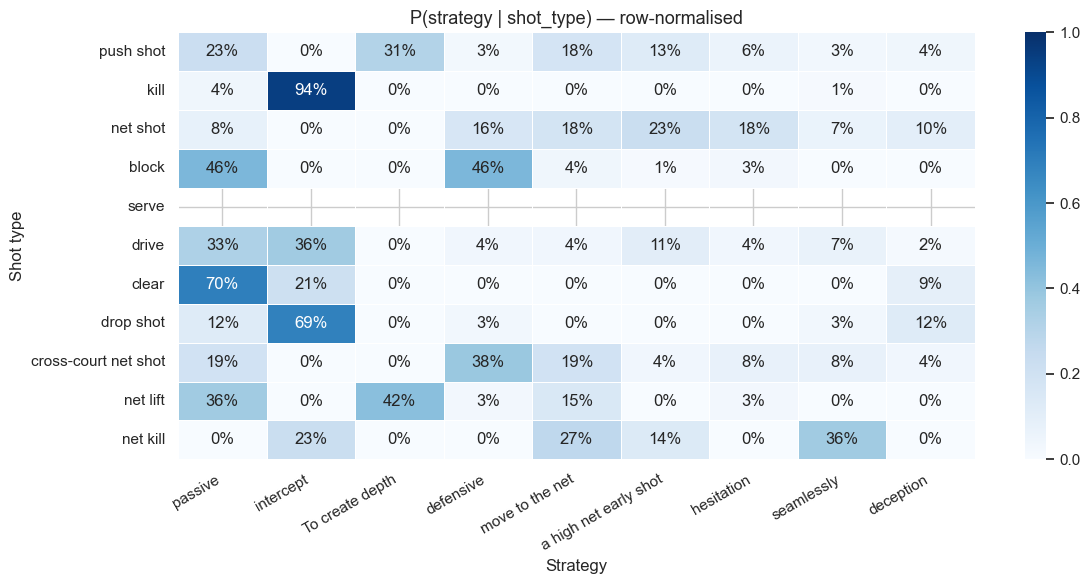

In [6]:
# Row-normalise: P(strategy | shot_type)
row_sums = matrix.sum(axis=1).replace(0, np.nan)
prob_matrix = matrix.div(row_sums, axis=0)

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(prob_matrix, annot=True, fmt='.0%', cmap='Blues', linewidths=0.5, ax=ax,
            vmin=0, vmax=1)
ax.set_title('P(strategy | shot_type) — row-normalised', fontsize=13)
ax.set_xlabel('Strategy')
ax.set_ylabel('Shot type')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('../results/eda_shot_strategy_prob.png', dpi=150)
plt.show()

## 6. Strategy entropy per shot type

Higher entropy = the shot type is used across many different strategies (harder to classify).  
Lower entropy = one dominant strategy (near-deterministic, easier).

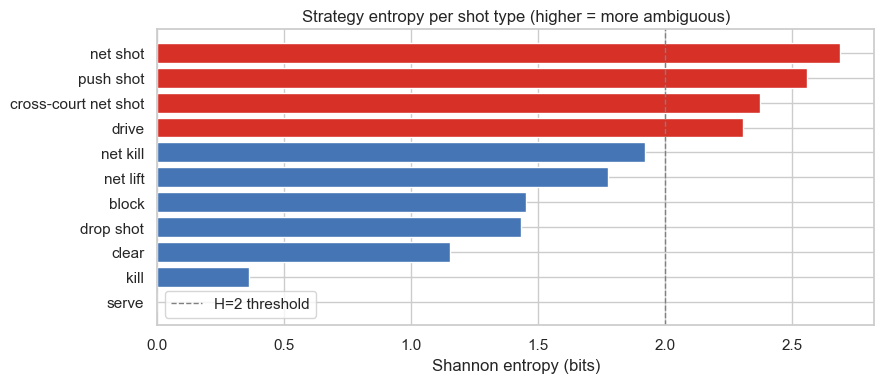

Near-deterministic shots (H < 1.5):
serve        0.000000
kill         0.362356
clear        1.152021
drop shot    1.434141
block        1.452079
dtype: float64

Ambiguous shots (H > 2.0):
drive                   2.308505
cross-court net shot    2.375880
push shot               2.557738
net shot                2.688948
dtype: float64


In [7]:
def entropy(row):
    total = row.sum()
    if total == 0:
        return 0.0
    probs = row[row > 0] / total
    return -(probs * np.log2(probs)).sum()

entropies = matrix.apply(entropy, axis=1).sort_values()

fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#d73027' if e > 2.0 else '#4575b4' for e in entropies]
bars = ax.barh(entropies.index, entropies.values, color=colors)
ax.axvline(x=2.0, color='grey', linestyle='--', linewidth=1, label='H=2 threshold')
ax.set_title('Strategy entropy per shot type (higher = more ambiguous)', fontsize=12)
ax.set_xlabel('Shannon entropy (bits)')
ax.legend()
plt.tight_layout()
plt.savefig('../results/eda_strategy_entropy.png', dpi=150)
plt.show()

print('Near-deterministic shots (H < 1.5):')
print(entropies[entropies < 1.5])
print('\nAmbiguous shots (H > 2.0):')
print(entropies[entropies > 2.0])

## 7. Dominant strategy per shot type (summary table)

In [8]:
rows = []
shot_totals = defaultdict(int)
for _, row in df.iterrows():
    ht = row['hit_type']
    if ht and isinstance(row.get('strategies'), list) and row['strategies']:
        shot_totals[ht] += 1

for ht in shot_types_ordered:
    if ht not in cross:
        continue
    top_strat, top_count = cross[ht].most_common(1)[0]
    total = shot_totals[ht]
    n_strats = len(cross[ht])
    H = entropy(matrix.loc[ht])
    rows.append({
        'Shot type': ht,
        'n (with strategy)': total,
        'Top strategy': top_strat,
        'P(top | shot)': f'{top_count/total:.0%}',
        'Num strategies': n_strats,
        'Entropy (bits)': f'{H:.2f}',
    })

summary = pd.DataFrame(rows).set_index('Shot type')
display(summary)

IndexError: list index out of range

## 8. Key findings

### Near-deterministic shot → strategy mappings
| Shot type | Dominant strategy | P(strategy\|shot) |
|---|---|---|
| kill | intercept | **99%** |
| net kill | seamlessly | **100%** |
| drop shot | intercept | **96%** |
| net lift | To create depth | **88%** |
| block | defensive / passive | **79%** |

Kill, drop shot, and net kill have near-perfect strategy predictability from the shot label alone — skeleton features may add marginal value for these classes.

### Ambiguous shots (where pose context matters most)
| Shot type | Entropy | Why ambiguous |
|---|---|---|
| net shot | 2.69 bits | Used across 7 strategies in both attack/defense |
| push shot | 2.56 bits | Transitional shot — context-dependent |
| drive | 2.31 bits | Intercept and passive co-occur |
| cross-court net shot | 2.38 bits | Defensive or attacking depending on court position |

These are where **skeleton + court position features should contribute the most discriminative power**.

### Strategy → shot diversity
- **intercept** is concentrated in kill/drop/drive — clean signal
- **To create depth** is almost exclusively push shot + net lift (2 shot types)
- **passive** / **defensive** span 7–9 shot types — these are the hardest strategy labels to model

### Class imbalance considerations
- Shot level: push shot (84) and kill (70) dominate; net kill (8) and drop shot (23) are rare
- Strategy level: passive (137) and intercept (120) are 2× more frequent than deception (21)
- Episodic sampling in ProtoNet training directly addresses this imbalance

## 9. Rally-level statistics

In [ ]:
rally_lengths = [len(r.get('hitting', [])) for r in data]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(rally_lengths, bins=15, color='steelblue', edgecolor='white')
axes[0].set_title('Shots per rally distribution')
axes[0].set_xlabel('Number of shots')
axes[0].set_ylabel('Frequency')

# Shots per video (proxy for rally difficulty)
shots_per_video = df.groupby('video').size().sort_values(ascending=False)
axes[1].bar(range(len(shots_per_video)), shots_per_video.values, color='coral')
axes[1].set_title('Shots per rally (video)')
axes[1].set_xlabel('Rally index (sorted)')
axes[1].set_ylabel('Shot count')

plt.tight_layout()
plt.savefig('../results/eda_rally_stats.png', dpi=150)
plt.show()

print(f'Mean shots/rally:   {np.mean(rally_lengths):.1f}')
print(f'Median shots/rally: {np.median(rally_lengths):.0f}')
print(f'Max shots/rally:    {max(rally_lengths)}')
print(f'Min shots/rally:    {min(rally_lengths)}')

## 10. Ball area × Strategy heatmap

Where on the court is each strategy executed? This reveals spatial patterns in tactical decision-making.

In [ ]:

# Build ball_area × strategy matrix (only shots with both fields)
area_strat = defaultdict(Counter)
for _, row in df.iterrows():
    area = row.get('ball_area', '')
    strats = row.get('strategies', [])
    if not area or not isinstance(strats, list):
        continue
    for st in strats:
        area_strat[area][st] += 1

# Court zones ordered front→back
AREA_ORDER = [
    'left front court', 'mid front court', 'right front court',
    'left mid court',   'mid court',        'right mid court',
    'left back court',  'mid back court',   'right back court',
]
# Only keep strategies in our canonical 5 + the excluded ones for full picture
strat_cols = [s for s, _ in strat_counts.most_common()]

area_mat = pd.DataFrame(
    [[area_strat[a][st] for st in strat_cols] for a in AREA_ORDER],
    index=AREA_ORDER, columns=strat_cols
).fillna(0).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Raw counts
sns.heatmap(area_mat, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.5, ax=axes[0])
axes[0].set_title('Ball area × Strategy (raw counts)', fontsize=13)
axes[0].set_xlabel('Strategy')
axes[0].set_ylabel('Ball area (front → back)')
axes[0].tick_params(axis='x', rotation=30)

# Row-normalised
row_s = area_mat.sum(axis=1).replace(0, np.nan)
area_prob = area_mat.div(row_s, axis=0)
sns.heatmap(area_prob, annot=True, fmt='.0%', cmap='Blues',
            linewidths=0.5, ax=axes[1], vmin=0, vmax=1)
axes[1].set_title('P(strategy | ball_area) — row-normalised', fontsize=13)
axes[1].set_xlabel('Strategy')
axes[1].set_ylabel('')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('../results/eda_area_strategy_heatmap.png', dpi=150)
plt.show()


## 11. Shot characteristics & Player actions

In [ ]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── 11a. Shot characteristics frequency ──────────────────────────────────────
all_chars = [c for row in df['shot_characteristics'].dropna()
             for c in (row if isinstance(row, list) else [])]
char_counts = Counter(all_chars)
labels_c, vals_c = zip(*char_counts.most_common())
axes[0].bar(labels_c, vals_c, color=sns.color_palette('muted', len(labels_c)))
axes[0].bar_label(axes[0].containers[0], padding=2)
axes[0].set_title('Shot characteristics frequency', fontsize=12)
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=35)

# ── 11b. Player action (forehand/backhand) by shot type ──────────────────────
action_shot = defaultdict(Counter)
for _, row in df.iterrows():
    ht = row.get('hit_type', '')
    for act in (row.get('player_actions') or []):
        action_shot[ht][act] += 1

shot_types_top = [t for t, _ in Counter(df['hit_type']).most_common(10) if t]
actions = ['forehand', 'backhand', 'turnaround']
action_mat = pd.DataFrame(
    [[action_shot[ht].get(a, 0) for a in actions] for ht in shot_types_top],
    index=shot_types_top, columns=actions
)
action_mat.plot(kind='bar', ax=axes[1], colormap='Set2', edgecolor='white', width=0.7)
axes[1].set_title('Player action by shot type (top 10)', fontsize=12)
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=35)
axes[1].legend(fontsize=9)

# ── 11c. Hitter position (top vs bottom) by strategy ─────────────────────────
hitter_strat = defaultdict(Counter)
for _, row in df.iterrows():
    hitter = row.get('hitter', '')
    for st in (row.get('strategies') or []):
        hitter_strat[st][hitter] += 1

strat_order_5 = ['passive', 'intercept', 'To create depth', 'defensive', 'move to the net']
hitter_mat = pd.DataFrame(
    [[hitter_strat[st].get(pos, 0) for pos in ['top', 'bottom']] for st in strat_order_5],
    index=strat_order_5, columns=['top (far side)', 'bottom (near side)']
)
hitter_mat.plot(kind='bar', ax=axes[2], color=['#4c72b0', '#dd8452'], edgecolor='white', width=0.6)
axes[2].set_title('Hitter position by strategy (top vs bottom court)', fontsize=12)
axes[2].set_ylabel('Count')
axes[2].tick_params(axis='x', rotation=30)
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig('../results/eda_shot_characteristics.png', dpi=150)
plt.show()


## 12. Shot duration analysis

Shot window length (frames) and its relationship to strategy — determines the temporal context available per sample.

In [ ]:

df['duration'] = (df['end_frame'] - df['start_frame']).clip(lower=0)
FPS = 20  # FineBadminton

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# ── 12a. Overall shot duration distribution ───────────────────────────────────
axes[0].hist(df['duration'].dropna(), bins=25, color='steelblue', edgecolor='white')
axes[0].axvline(df['duration'].median(), color='tomato', linestyle='--', label=f'Median={df["duration"].median():.0f}')
axes[0].axvline(16, color='goldenrod', linestyle='--', linewidth=1.5, label='shot_window=16')
axes[0].set_title('Shot duration (frames @ 20 fps)', fontsize=12)
axes[0].set_xlabel('Duration (frames)')
axes[0].set_ylabel('Count')
axes[0].legend()

# ── 12b. Shot duration by shot type (boxplot) ────────────────────────────────
shot_dur_data = [df[df['hit_type'] == ht]['duration'].dropna().values
                 for ht in shot_types_ordered]
bp = axes[1].boxplot(shot_dur_data, labels=shot_types_ordered, patch_artist=True,
                     medianprops=dict(color='tomato', linewidth=2))
colors_bp = sns.color_palette('muted', len(shot_types_ordered))
for patch, color in zip(bp['boxes'], colors_bp):
    patch.set_facecolor(color)
axes[1].axhline(16, color='goldenrod', linestyle='--', linewidth=1.2, label='shot_window=16')
axes[1].set_title('Shot duration by shot type', fontsize=12)
axes[1].set_xlabel('Shot type')
axes[1].set_ylabel('Duration (frames)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(fontsize=9)

# ── 12c. Shot duration by strategy ───────────────────────────────────────────
CANONICAL_5 = ['passive', 'intercept', 'To create depth', 'defensive', 'move to the net']
strat_dur = {st: [] for st in CANONICAL_5}
for _, row in df.iterrows():
    dur = row.get('duration', np.nan)
    if np.isnan(dur):
        continue
    for st in (row.get('strategies') or []):
        if st in strat_dur:
            strat_dur[st].append(dur)

bp2 = axes[2].boxplot([strat_dur[st] for st in CANONICAL_5],
                      labels=[s.replace('To create depth', 'create_depth') for s in CANONICAL_5],
                      patch_artist=True, medianprops=dict(color='tomato', linewidth=2))
colors_bp2 = sns.color_palette('Set2', len(CANONICAL_5))
for patch, color in zip(bp2['boxes'], colors_bp2):
    patch.set_facecolor(color)
axes[2].axhline(16, color='goldenrod', linestyle='--', linewidth=1.2, label='shot_window=16')
axes[2].set_title('Shot duration by strategy', fontsize=12)
axes[2].set_xlabel('Strategy')
axes[2].set_ylabel('Duration (frames)')
axes[2].tick_params(axis='x', rotation=25)
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig('../results/eda_shot_duration.png', dpi=150)
plt.show()

print(f'Shots shorter than shot_window (16 frames): {(df["duration"] < 16).sum()} ({(df["duration"] < 16).mean():.0%})')
print(f'Shots longer than shot_window (16 frames):  {(df["duration"] >= 16).sum()} ({(df["duration"] >= 16).mean():.0%})')
print(f'\nMean duration: {df["duration"].mean():.1f} frames  ({df["duration"].mean()/FPS*1000:.0f} ms)')
print(f'Median duration: {df["duration"].median():.0f} frames  ({df["duration"].median()/FPS*1000:.0f} ms)')


## 13. Skeleton data quality

How many frames are available per rally? Are skeleton sequences long enough for our shot window of T=16?

In [ ]:

import sys
sys.path.insert(0, '..')
from pathlib import Path

SK_DIR = Path('../datasets_preprocessing/finebadminton_skeletons')
SK_DIR_GDINO = Path('../datasets_preprocessing/finebadminton_skeletons_gdino_v2')

sk_files = sorted(SK_DIR.glob('*.npy'))
sk_info = []
for f in sk_files:
    arr = np.load(f)  # shape: (2, T, 34) or (T, 2, 17, 2)
    # Normalise to (2, T, 34) view
    if arr.ndim == 4:  # (T, 2, 17, 2) → reshape
        T = arr.shape[0]
    else:
        T = arr.shape[1]
    sk_info.append({'rally': f.stem, 'frames': T})

sk_df = pd.DataFrame(sk_info)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# ── 13a. Skeleton frames per rally histogram ──────────────────────────────────
axes[0].hist(sk_df['frames'], bins=15, color='mediumpurple', edgecolor='white')
axes[0].axvline(sk_df['frames'].median(), color='tomato', linestyle='--',
                label=f'Median={sk_df["frames"].median():.0f}')
axes[0].set_title('Skeleton frames per rally (YOLOv8)', fontsize=12)
axes[0].set_xlabel('Number of frames')
axes[0].set_ylabel('Rally count')
axes[0].legend()

# ── 13b. Frames vs shots in same rally ───────────────────────────────────────
shots_per_rally = df.groupby('video').size().reset_index(name='n_shots')
shots_per_rally['rally'] = shots_per_rally['video'].str.replace('.mp4', '', regex=False)
merged = sk_df.merge(shots_per_rally, on='rally', how='left')

axes[1].scatter(merged['n_shots'], merged['frames'],
                alpha=0.7, color='steelblue', edgecolors='white', s=60)
axes[1].set_title('Skeleton frames vs shots per rally', fontsize=12)
axes[1].set_xlabel('Shots in rally')
axes[1].set_ylabel('Skeleton frames available')
# Add reference line: 16 frames per shot
x_ref = np.linspace(0, merged['n_shots'].max() + 1, 50)
axes[1].plot(x_ref, x_ref * 16, 'r--', linewidth=1.2, label='16 frames/shot (required)')
axes[1].legend(fontsize=9)

# ── 13c. GDINO vs YOLOv8 frame counts ────────────────────────────────────────
if SK_DIR_GDINO.exists():
    gd_files = sorted(SK_DIR_GDINO.glob('*.npy'))
    gd_info = {}
    for f in gd_files:
        arr = np.load(f)
        T = arr.shape[1] if arr.ndim == 3 else arr.shape[0]
        gd_info[f.stem] = T

    sk_df['gdino_frames'] = sk_df['rally'].map(gd_info)
    both = sk_df.dropna(subset=['gdino_frames'])
    axes[2].scatter(both['frames'], both['gdino_frames'],
                    alpha=0.7, color='darkorange', edgecolors='white', s=60)
    mn = min(both['frames'].min(), both['gdino_frames'].min())
    mx = max(both['frames'].max(), both['gdino_frames'].max())
    axes[2].plot([mn, mx], [mn, mx], 'k--', linewidth=1, label='y=x')
    axes[2].set_title('YOLOv8 vs GDINO-guided skeleton frames', fontsize=12)
    axes[2].set_xlabel('YOLOv8 frames')
    axes[2].set_ylabel('GDINO frames')
    axes[2].legend(fontsize=9)
else:
    axes[2].text(0.5, 0.5, 'GDINO v2 not found', ha='center', va='center',
                 transform=axes[2].transAxes)
    axes[2].set_title('GDINO vs YOLOv8 (unavailable)', fontsize=12)

plt.tight_layout()
plt.savefig('../results/eda_skeleton_quality.png', dpi=150)
plt.show()

print(sk_df[['rally', 'frames']].describe())


## 14. Mean skeleton pose per strategy

Average 2D joint positions (P0 = top-court, P1 = bottom-court) grouped by strategy. Visualises how body posture differs between tactics.

In [ ]:

# COCO skeleton edges for stick-figure drawing
EDGES = [
    (0,1),(0,2),(1,3),(2,4),
    (5,6),(5,7),(7,9),(6,8),(8,10),
    (5,11),(6,12),(11,12),
    (11,13),(13,15),(12,14),(14,16),
]

def draw_stick(ax, joints, color, alpha=0.7, lw=1.5, ms=4):
    """joints: (17,2) array of [x,y]"""
    for a, b in EDGES:
        if joints[a, 0] > 0 and joints[b, 0] > 0:
            ax.plot([joints[a,0], joints[b,0]], [joints[a,1], joints[b,1]],
                    '-', color=color, alpha=alpha, lw=lw)
    valid = joints[:, 0] > 0
    ax.scatter(joints[valid, 0], joints[valid, 1],
               color=color, s=ms**2, alpha=alpha, zorder=3)

# Build strategy → list of (17,2) hit-frame poses for each player
strat_poses = {st: {'P0': [], 'P1': []} for st in CANONICAL_5}

for _, row in df.iterrows():
    strats = row.get('strategies', [])
    video = str(row.get('video', '')).replace('.mp4', '')
    hit_frame = row.get('hit_frame', None)
    if not strats or hit_frame is None:
        continue

    sk_path = SK_DIR / f'{video}.npy'
    if not sk_path.exists():
        continue

    sk = np.load(sk_path)  # (2, T, 34)  dim0=[x,y], dim1=frames, dim2=joints

    # Map absolute hit_frame → relative index within this rally's skeleton
    # Skeleton was extracted frame-by-frame starting from the rally start_frame
    # We need to know the rally's start_frame
    rally_meta = next((r for r in data if r['video'] == row['video']), None)
    if rally_meta is None:
        continue
    rel_idx = hit_frame - rally_meta['start_frame']
    if rel_idx < 0 or rel_idx >= sk.shape[1]:
        continue

    frame_sk = sk[:, rel_idx, :]  # (2, 34)  row0=x, row1=y
    # Reshape to (17, 2) per player
    p0 = np.stack([frame_sk[0, :17], frame_sk[1, :17]], axis=1)   # (17,2)
    p1 = np.stack([frame_sk[0, 17:], frame_sk[1, 17:]], axis=1)  # (17,2)

    for st in strats:
        if st in strat_poses:
            strat_poses[st]['P0'].append(p0)
            strat_poses[st]['P1'].append(p1)

# Plot mean poses
STRAT_LABELS = ['passive', 'intercept', 'To create depth', 'defensive', 'move to the net']
STRAT_SHORT  = ['passive', 'intercept', 'create_depth', 'defensive', 'move_to_net']
P0_COLOR = '#2196F3'
P1_COLOR = '#F44336'

fig, axes = plt.subplots(2, 5, figsize=(20, 8))

for col, (st, label) in enumerate(zip(STRAT_LABELS, STRAT_SHORT)):
    for row_idx, player in enumerate(['P0', 'P1']):
        ax = axes[row_idx][col]
        poses = strat_poses[st][player]
        if poses:
            arr = np.array(poses)  # (N, 17, 2)
            # Zero-out invalid joints (x==0) before averaging
            valid_mask = arr[:, :, 0] > 0  # (N, 17)
            mean_pose = np.zeros((17, 2))
            for j in range(17):
                vj = valid_mask[:, j]
                if vj.sum() > 0:
                    mean_pose[j] = arr[vj, j, :].mean(axis=0)
            color = P0_COLOR if player == 'P0' else P1_COLOR
            draw_stick(ax, mean_pose, color=color, lw=2, ms=5)
            ax.set_xlim(0, 1280)
            ax.set_ylim(720, 0)  # flip y (image coords)
        ax.set_title(f'{label}\n{player} (n={len(poses)})', fontsize=9)
        ax.set_aspect('equal')
        ax.axis('off')

axes[0][0].set_ylabel('P0 (top court)', fontsize=10)
axes[1][0].set_ylabel('P1 (bottom court)', fontsize=10)

fig.suptitle('Mean skeleton pose at hit frame per strategy (FineBadminton)',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../results/eda_mean_pose_per_strategy.png', dpi=150, bbox_inches='tight')
plt.show()


## 15. Shuttle trajectory analysis

Shuttle x,y positions across rallies — coverage and density across the court.

In [ ]:

SHUTTLE_DIR = Path('../datasets_preprocessing/finebadminton_shuttles')
shuttle_files = sorted(SHUTTLE_DIR.glob('*.npy'))

all_x, all_y = [], []
traj_lengths = []
vis_rates = []

for f in shuttle_files:
    arr = np.load(f)  # (T, 3): [x, y, visibility]
    traj_lengths.append(len(arr))
    vis = arr[:, 2]
    vis_rates.append((vis > 0).mean())
    valid = arr[arr[:, 2] > 0]
    if len(valid):
        all_x.extend(valid[:, 0].tolist())
        all_y.extend(valid[:, 1].tolist())

all_x = np.array(all_x)
all_y = np.array(all_y)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── 15a. Shuttle position density (heatmap overlay on court) ─────────────────
h = axes[0].hist2d(all_x, all_y, bins=[40, 30],
                   range=[[0, 1280], [0, 720]],
                   cmap='hot_r', density=True)
plt.colorbar(h[3], ax=axes[0], label='density')
# Draw rough court lines
for y_line in [50, 670]:
    axes[0].axhline(y_line, color='white', lw=1, alpha=0.7)
for x_line in [80, 1200]:
    axes[0].axvline(x_line, color='white', lw=1, alpha=0.7)
axes[0].axhline(360, color='cyan', lw=1.2, linestyle='--', alpha=0.8, label='net')
axes[0].set_title('Shuttle position density (visible frames only)', fontsize=12)
axes[0].set_xlabel('x (px)')
axes[0].set_ylabel('y (px)')
axes[0].set_xlim(0, 1280)
axes[0].set_ylim(720, 0)
axes[0].legend(fontsize=9)

# ── 15b. Shuttle trajectory lengths ──────────────────────────────────────────
axes[1].hist(traj_lengths, bins=15, color='darkcyan', edgecolor='white')
axes[1].axvline(np.median(traj_lengths), color='tomato', linestyle='--',
                label=f'Median={np.median(traj_lengths):.0f}')
axes[1].set_title('Shuttle trajectory length per rally', fontsize=12)
axes[1].set_xlabel('Frames in rally')
axes[1].set_ylabel('Count')
axes[1].legend()

# ── 15c. Shuttle visibility rate per rally ────────────────────────────────────
axes[2].hist(vis_rates, bins=15, color='goldenrod', edgecolor='white')
axes[2].axvline(np.median(vis_rates), color='tomato', linestyle='--',
                label=f'Median={np.median(vis_rates):.0%}')
axes[2].set_title('Shuttle visibility rate per rally', fontsize=12)
axes[2].set_xlabel('Fraction of frames where shuttle visible')
axes[2].set_ylabel('Count')
axes[2].legend()

plt.tight_layout()
plt.savefig('../results/eda_shuttle_analysis.png', dpi=150)
plt.show()

print(f'Total rallies with shuttle data: {len(shuttle_files)}')
print(f'Mean visibility rate: {np.mean(vis_rates):.1%}')
print(f'Mean trajectory length: {np.mean(traj_lengths):.0f} frames')


## 16. Shot quality distribution

The annotation includes a 1–5 quality score. Higher quality shots may correlate with clearer tactical intent.

In [ ]:

df['quality_num'] = pd.to_numeric(df['quality'], errors='coerce')

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# ── 16a. Overall quality distribution ────────────────────────────────────────
q_counts = df['quality_num'].value_counts().sort_index()
axes[0].bar(q_counts.index.astype(str), q_counts.values, color=sns.color_palette('Blues_d', len(q_counts)))
axes[0].bar_label(axes[0].containers[0], padding=2)
axes[0].set_title('Shot quality score distribution', fontsize=12)
axes[0].set_xlabel('Quality (1=poor … 5=excellent)')
axes[0].set_ylabel('Count')

# ── 16b. Quality by shot type ────────────────────────────────────────────────
q_by_shot = df.groupby('hit_type')['quality_num'].mean().reindex(shot_types_ordered)
colors_q = ['#d73027' if v < 3 else '#4575b4' for v in q_by_shot]
axes[1].barh(q_by_shot.index, q_by_shot.values, color=colors_q)
axes[1].axvline(df['quality_num'].mean(), color='grey', linestyle='--',
                label=f'Mean={df["quality_num"].mean():.2f}')
axes[1].set_title('Mean quality score by shot type', fontsize=12)
axes[1].set_xlabel('Mean quality')
axes[1].legend(fontsize=9)

# ── 16c. Quality by strategy ─────────────────────────────────────────────────
q_by_strat = {}
for _, row in df.iterrows():
    q = row.get('quality_num', np.nan)
    if np.isnan(q):
        continue
    for st in (row.get('strategies') or []):
        if st in CANONICAL_5:
            q_by_strat.setdefault(st, []).append(q)

strat_short_names = [s.replace('To create depth', 'create_depth') for s in CANONICAL_5]
means = [np.mean(q_by_strat.get(st, [0])) for st in CANONICAL_5]
stds  = [np.std(q_by_strat.get(st, [0]))  for st in CANONICAL_5]

axes[2].bar(strat_short_names, means, yerr=stds, capsize=4,
            color=sns.color_palette('Set2', len(CANONICAL_5)), edgecolor='white')
axes[2].axhline(df['quality_num'].mean(), color='grey', linestyle='--',
                label=f'Overall mean={df["quality_num"].mean():.2f}')
axes[2].set_title('Mean quality score by strategy (±1 SD)', fontsize=12)
axes[2].set_xlabel('Strategy')
axes[2].set_ylabel('Mean quality')
axes[2].tick_params(axis='x', rotation=25)
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig('../results/eda_quality_distribution.png', dpi=150)
plt.show()


## 17. Summary dashboard

A single-page summary figure for the report.

In [ ]:

fig = plt.figure(figsize=(20, 14))
fig.suptitle('FineBadminton EDA Summary', fontsize=16, y=0.98)

gs = fig.add_gridspec(3, 4, hspace=0.5, wspace=0.35)

# ── A: Shot type distribution ─────────────────────────────────────────────────
ax_a = fig.add_subplot(gs[0, :2])
shot_counts_plot = shot_counts.drop('', errors='ignore')
bars_a = ax_a.bar(shot_counts_plot.index, shot_counts_plot.values,
                  color=sns.color_palette('muted', len(shot_counts_plot)))
ax_a.bar_label(bars_a, padding=2, fontsize=8)
ax_a.set_title('(A) Shot-type distribution', fontsize=11)
ax_a.set_ylabel('Count')
ax_a.tick_params(axis='x', rotation=35, labelsize=8)

# ── B: Strategy distribution ──────────────────────────────────────────────────
ax_b = fig.add_subplot(gs[0, 2:])
bars_b = ax_b.bar(labels, values, color=sns.color_palette('Set2', len(labels)))
ax_b.bar_label(bars_b, padding=2, fontsize=8)
ax_b.set_title('(B) Strategy distribution', fontsize=11)
ax_b.set_ylabel('Count')
ax_b.tick_params(axis='x', rotation=35, labelsize=8)

# ── C: Shot × Strategy heatmap ────────────────────────────────────────────────
ax_c = fig.add_subplot(gs[1, :2])
# Use only canonical 5 strategies for clarity
canon_cols = ['passive', 'intercept', 'To create depth', 'defensive', 'move to the net']
matrix_5 = matrix[[c for c in canon_cols if c in matrix.columns]]
sns.heatmap(matrix_5, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.5, ax=ax_c, cbar=False, annot_kws={'size': 8})
ax_c.set_title('(C) Shot × Strategy co-occurrence', fontsize=11)
ax_c.set_xlabel('Strategy', fontsize=9)
ax_c.set_ylabel('Shot type', fontsize=9)
ax_c.tick_params(axis='x', rotation=30, labelsize=7)
ax_c.tick_params(axis='y', labelsize=7)

# ── D: Strategy entropy ───────────────────────────────────────────────────────
ax_d = fig.add_subplot(gs[1, 2:])
ent_colors = ['#d73027' if e > 2.0 else '#4575b4' for e in entropies]
ax_d.barh(entropies.index, entropies.values, color=ent_colors)
ax_d.axvline(x=2.0, color='grey', linestyle='--', linewidth=1)
ax_d.set_title('(D) Strategy entropy per shot type', fontsize=11)
ax_d.set_xlabel('Shannon entropy (bits)', fontsize=9)
ax_d.tick_params(labelsize=8)

# ── E: Shot duration ──────────────────────────────────────────────────────────
ax_e = fig.add_subplot(gs[2, :1])
ax_e.hist(df['duration'].dropna(), bins=20, color='steelblue', edgecolor='white')
ax_e.axvline(16, color='goldenrod', linestyle='--', lw=1.5, label='T=16')
ax_e.axvline(df['duration'].median(), color='tomato', linestyle='--', lw=1.2,
             label=f'Med={df["duration"].median():.0f}')
ax_e.set_title('(E) Shot duration (frames)', fontsize=11)
ax_e.set_xlabel('Frames')
ax_e.set_ylabel('Count')
ax_e.legend(fontsize=7)
ax_e.tick_params(labelsize=8)

# ── F: Rally length histogram ─────────────────────────────────────────────────
ax_f = fig.add_subplot(gs[2, 1:2])
ax_f.hist(rally_lengths, bins=12, color='coral', edgecolor='white')
ax_f.set_title('(F) Shots per rally', fontsize=11)
ax_f.set_xlabel('Shots')
ax_f.set_ylabel('Rallies')
ax_f.tick_params(labelsize=8)

# ── G: Shuttle visibility ─────────────────────────────────────────────────────
ax_g = fig.add_subplot(gs[2, 2:3])
ax_g.hist(vis_rates, bins=12, color='goldenrod', edgecolor='white')
ax_g.axvline(np.median(vis_rates), color='tomato', linestyle='--',
             label=f'Med={np.median(vis_rates):.0%}')
ax_g.set_title('(G) Shuttle visibility rate', fontsize=11)
ax_g.set_xlabel('Fraction visible')
ax_g.set_ylabel('Rallies')
ax_g.legend(fontsize=7)
ax_g.tick_params(labelsize=8)

# ── H: Skeleton frames per rally ─────────────────────────────────────────────
ax_h = fig.add_subplot(gs[2, 3:])
ax_h.hist(sk_df['frames'], bins=12, color='mediumpurple', edgecolor='white')
ax_h.axvline(sk_df['frames'].median(), color='tomato', linestyle='--',
             label=f'Med={sk_df["frames"].median():.0f}')
ax_h.set_title('(H) Skeleton frames/rally', fontsize=11)
ax_h.set_xlabel('Frames')
ax_h.set_ylabel('Rallies')
ax_h.legend(fontsize=7)
ax_h.tick_params(labelsize=8)

plt.savefig('../results/eda_summary_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dashboard saved → results/eda_summary_dashboard.png')
